# Projet Getaround - Analyse des retards et modélisation du prix

Ce notebook regroupe l'analyse exploratoire des retards de restitution sur la plateforme Getaround et la construction d'un modèle de Machine Learning pour la suggestion du prix de location journalier.

**Plan du document**

1. Chargement et exploration des données de retards
2. Analyse des retards à la restitution
3. Locations chaînées et impact sur le conducteur suivant
4. Simulation des seuils - arbitrage business
5. Modélisation du prix de location
6. Conclusion et recommandations


## 1. Chargement et exploration des données de retards

Le fichier `get_around_delay_analysis.xlsx` contient l'historique des locations avec, pour chacune, le délai de restitution et l'identifiant de la location précédente (le cas échéant).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('colorblind')
plt.rcParams['figure.dpi'] = 100

# Chemin portable : on cherche le dossier 'data' soit à la racine du projet,
# soit dans le dossier du notebook, soit un niveau au-dessus.
from pathlib import Path
_candidates = [Path('../data'), Path('data'), Path('./data'), Path('../../data')]
DATA_DIR = next((p for p in _candidates if p.exists()), None)
if DATA_DIR is None:
    raise FileNotFoundError("Dossier 'data' introuvable. Vérifiez votre arborescence.")

df = pd.read_excel(DATA_DIR / 'get_around_delay_analysis.xlsx')
print(f'Dimensions : {df.shape[0]} locations - {df.shape[1]} variables')
print(f'Véhicules uniques : {df["car_id"].nunique()}')
df.head()

Dimensions : 21310 locations - 7 variables
Véhicules uniques : 8143


,rental_id,car_id,checkin_type,state,delay_at_checkout_in_minutes,previous_ended_rental_id,time_delta_with_previous_rental_in_minutes
0,505000,363965,mobile,canceled,NaN,NaN,NaN
1,507750,269550,mobile,ended,-81.0,NaN,NaN
2,508131,359049,connect,ended,70.0,NaN,NaN
3,508865,299063,connect,canceled,NaN,NaN,NaN
4,511440,313932,mobile,ended,NaN,NaN,NaN


**Observation** : le jeu de données comporte 21 310 locations couvrant 8 143 véhicules distincts. Chaque ligne correspond à une location, avec des informations sur le type de check-in, l'état (terminée, annulée), le délai de restitution et, pour les locations chaînées, l'écart prévu et l'identifiant de la location précédente.

In [2]:
print('Répartition par type de check-in :')
print(df['checkin_type'].value_counts())
print('\nRépartition par état :')
print(df['state'].value_counts())
print('\nCroisement type x état :')
print(pd.crosstab(df['checkin_type'], df['state'], margins=True))

Répartition par type de check-in :
checkin_type
mobile     17003
connect     4307
Name: count, dtype: int64

Répartition par état :
state
ended       18045
canceled     3265
Name: count, dtype: int64

Croisement type x état :
state         canceled  ended    All
checkin_type                        
connect            798   3509   4307
mobile            2467  14536  17003
All               3265  18045  21310


**Observation** :

- Le canal **mobile** représente 79,8 % des locations contre 20,2 % pour le canal **connect**.
- 84,7 % des locations vont jusqu'à leur terme, 15,3 % sont annulées.
- Le taux d'annulation est plus élevé sur le canal connect (18,5 %) que sur mobile (14,5 %), ce qui peut sembler contre-intuitif et mérite d'être croisé avec la durée et le profil des locations.

## 2. Analyse des retards à la restitution

Pour les locations terminées et dont le délai est renseigné, on étudie la distribution du retard au moment de la restitution.

In [3]:
ended = df[df['state'] == 'ended'].copy()
delays = ended.dropna(subset=['delay_at_checkout_in_minutes']).copy()

print(f'Locations analysables : {len(delays)} sur {len(ended)} terminées')
print('\nStatistiques du délai (minutes) :')
print(delays['delay_at_checkout_in_minutes'].describe().round(2))
print('\nQuantiles :')
print(delays['delay_at_checkout_in_minutes'].quantile([0.05, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]).round(1))

Locations analysables : 16345 sur 18045 terminées

Statistiques du délai (minutes) :
count    16345.00
mean        60.77
std        993.17
min     -22433.00
25%        -36.00
50%          9.00
75%         67.00
max      71084.00
Name: delay_at_checkout_in_minutes, dtype: float64

Quantiles :
0.05    -230.0
0.25     -36.0
0.50       9.0
0.75      67.0
0.90     193.0
0.95     397.8
0.99    1490.6
Name: delay_at_checkout_in_minutes, dtype: float64


**Observation** : la distribution du délai de restitution est très étalée. La médiane se situe à +9 minutes (donc une légère tendance au retard), mais la queue de distribution est lourde : le 95ᵉ centile est à environ 397 minutes (6h30) et le 99ᵉ à près de 1 490 minutes (24 h). La moyenne (≈ 61 min) est tirée vers le haut par ces valeurs extrêmes : la médiane est un indicateur plus fiable du comportement central.

In [4]:
late = (delays['delay_at_checkout_in_minutes'] > 0).sum()
on_time = (delays['delay_at_checkout_in_minutes'] == 0).sum()
early = (delays['delay_at_checkout_in_minutes'] < 0).sum()

print(f'En avance : {early} ({early/len(delays)*100:.1f}%)')
print(f"À l'heure : {on_time} ({on_time/len(delays)*100:.1f}%)")
print(f'En retard : {late} ({late/len(delays)*100:.1f}%)')

print('\nTaux de retard par type :')
for t in ['connect', 'mobile']:
    sub = delays[delays['checkin_type'] == t]
    n_late = (sub['delay_at_checkout_in_minutes'] > 0).sum()
    print(f'  {t:8s} : {n_late/len(sub)*100:.2f}% en retard (n={len(sub)})')
    print(f'           médiane = {sub["delay_at_checkout_in_minutes"].median():.0f} min')

En avance : 6819 (41.7%)
À l'heure : 122 (0.7%)
En retard : 9404 (57.5%)

Taux de retard par type :
  connect  : 42.89% en retard (n=3402)
           médiane = -9 min
  mobile   : 61.38% en retard (n=12943)
           médiane = 14 min


**Observation** :

- **57,5 % des restitutions sont en retard** (9 404 sur 16 345 analysables), 41,7 % en avance et 0,7 % à l'heure exacte.
- Le canal **Connect** est nettement plus discipliné : 42,9 % de retards seulement, avec un délai médian négatif (-9 minutes, donc en avance). Cela peut s'expliquer par l'absence de remise des clefs en main propre, qui évite les délais de courtoisie liés à la rencontre physique.
- Le canal **Mobile** présente 61,4 % de retards avec un délai médian de +14 minutes.

Ce constat est important : si un seuil de blocage doit être appliqué, sa pertinence varie selon le canal.

## 3. Locations chaînées et impact sur le conducteur suivant

Une location est dite *chaînée* lorsqu'elle suit immédiatement une autre location du même véhicule. On joint chaque location chaînée avec le délai de restitution de la précédente afin de mesurer l'attente effective subie par le conducteur suivant.

In [5]:
prev_info = df[['rental_id', 'delay_at_checkout_in_minutes', 'state']].rename(
    columns={'rental_id': 'previous_ended_rental_id',
             'delay_at_checkout_in_minutes': 'previous_delay',
             'state': 'previous_state'}
)

chained = df.dropna(subset=['previous_ended_rental_id']).merge(
    prev_info, on='previous_ended_rental_id', how='left'
)

chained_full = chained.dropna(subset=['previous_delay']).copy()
chained_full['impact_minutes'] = (
    chained_full['previous_delay']
    - chained_full['time_delta_with_previous_rental_in_minutes']
)
chained_full['problematic'] = chained_full['impact_minutes'] > 0
chained_full['previous_was_late'] = chained_full['previous_delay'] > 0

print(f'Locations chaînées : {len(chained)} ({len(chained)/len(df)*100:.2f}%)')
print(f'Avec délai précédent renseigné : {len(chained_full)}')
print(f'Cas problématiques (retard > écart prévu) : {chained_full["problematic"].sum()} '
      f'({chained_full["problematic"].mean()*100:.1f}%)')

Locations chaînées : 1841 (8.64%)
Avec délai précédent renseigné : 1729
Cas problématiques (retard > écart prévu) : 218 (12.6%)


**Observation** : sur 21 310 locations, seules **1 841 (8,6 %)** sont chaînées. Parmi celles dont on connaît le délai précédent (1 729 locations), **218 cas problématiques** sont identifiés : le retard du conducteur précédent dépasse l'écart prévu entre les deux locations, ce qui se traduit par une attente directe pour le conducteur suivant. Cela représente **12,6 % des chaînages renseignés**, soit environ **1 % de l'ensemble des locations**.

In [6]:
prob = chained_full[chained_full['problematic']]
print(f"Attente moyenne quand il y a problème : {prob['impact_minutes'].mean():.0f} min")
print(f"Attente médiane : {prob['impact_minutes'].median():.0f} min")
print(f"Attente maximum : {prob['impact_minutes'].max():.0f} min")

cancel_late = chained_full[chained_full['previous_was_late']]['state'].value_counts(normalize=True).get('canceled', 0) * 100
cancel_not = chained_full[~chained_full['previous_was_late']]['state'].value_counts(normalize=True).get('canceled', 0) * 100
print(f"\nTaux d'annulation quand précédent en retard : {cancel_late:.2f}%")
print(f"Taux d'annulation sinon                      : {cancel_not:.2f}%")
print(f"Ratio : x{cancel_late/cancel_not:.2f}")

Attente moyenne quand il y a problème : 178 min
Attente médiane : 26 min
Attente maximum : 12548 min

Taux d'annulation quand précédent en retard : 12.14%
Taux d'annulation sinon                      : 11.68%
Ratio : x1.04


**Observation** :

- Lorsqu'un cas problématique survient, l'attente est de **27 minutes en médiane** mais peut grimper à 178 minutes en moyenne (queue extrême : un cas extrême atteint plus de 12 000 minutes, soit plus de 8 jours).
- Le taux d'annulation côté conducteur suivant est de 12,14 % lorsque le précédent était en retard, contre 11,68 % sinon. L'effet est modeste (x1,04), ce qui suggère que la majorité des frictions générées par les retards se traduisent par une attente effective plutôt que par une annulation. Cela renforce l'idée que la métrique cible doit être **l'attente subie** plus que l'annulation pure.

## 4. Simulation des seuils - arbitrage business

On simule l'effet d'un seuil de délai minimum sur les chaînages, en croisant deux paramètres : la **portée** (toutes les voitures, Connect uniquement, Mobile uniquement) et le **seuil** (de 15 à 360 minutes).

In [7]:
thresholds = [15, 30, 60, 90, 120, 180, 240, 360]

results = []
for scope, sdf in [('Tous', chained_full),
                   ('Connect', chained_full[chained_full['checkin_type'] == 'connect']),
                   ('Mobile', chained_full[chained_full['checkin_type'] == 'mobile'])]:
    for t in thresholds:
        blocked = (sdf['time_delta_with_previous_rental_in_minutes'] < t).sum()
        prob_total = sdf['problematic'].sum()
        prob_solved = ((sdf['time_delta_with_previous_rental_in_minutes'] < t)
                       & sdf['problematic']).sum()
        results.append({
            'Portée': scope,
            'Seuil (min)': t,
            'Bloqués': blocked,
            '% chaînages': f"{blocked/len(sdf)*100:.1f}%",
            '% CA total': f"{blocked/len(df)*100:.2f}%",
            'Résolus': prob_solved,
            '% problèmes résolus': f"{prob_solved/prob_total*100:.1f}%" if prob_total else 'N/A'
        })

results_df = pd.DataFrame(results)
results_df

,Portée,Seuil (min),Bloqués,% chaînages,% CA total,Résolus,% problèmes résolus
0,Tous,15,261,15.1%,1.22%,116,53.2%
1,Tous,30,261,15.1%,1.22%,116,53.2%
2,Tous,60,381,22.0%,1.79%,146,67.0%
3,Tous,90,550,31.8%,2.58%,172,78.9%
4,Tous,120,630,36.4%,2.96%,180,82.6%
5,Tous,180,828,47.9%,3.89%,196,89.9%
6,Tous,240,951,55.0%,4.46%,202,92.7%
7,Tous,360,1112,64.3%,5.22%,208,95.4%
8,Connect,15,127,16.1%,0.60%,40,58.0%
9,Connect,30,127,16.1%,0.60%,40,58.0%


**Observation** : la lecture du tableau permet de visualiser le compromis entre **protection du conducteur suivant** (% de cas problématiques résolus) et **impact business** (% du CA total impacté).

Quelques points de repère :

- **Seuil 60 min sur tous** : 22 % des chaînages bloqués, **67 % des cas problématiques résolus**, impact CA ~1,8 %.
- **Seuil 120 min sur tous** : 36 % des chaînages bloqués, **83 % des cas problématiques résolus**, impact CA ~3 %.
- **Seuil 60 min sur Connect** : impact CA **inférieur à 1 %**, **70 % des cas problématiques Connect résolus**.

Le canal Connect offre un meilleur ratio efficacité/coût car les chaînages courts y sont plus fréquents.

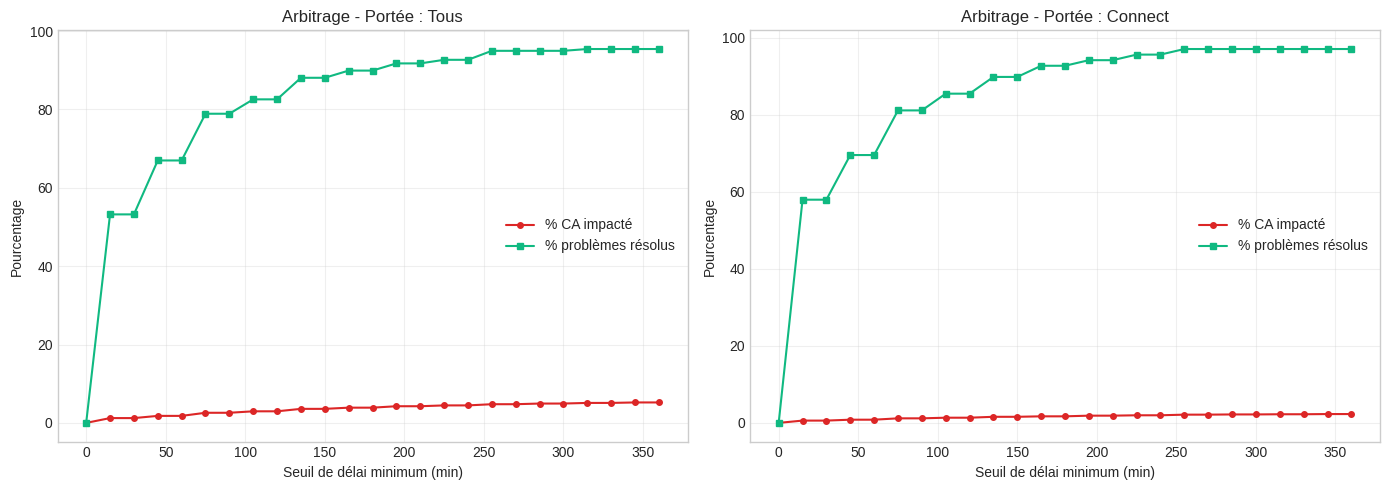

In [8]:
# Visualisation : courbes d'arbitrage
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for scope, color, ax in [('Tous', '#1f77b4', axes[0]), ('Connect', '#ff7f0e', axes[1])]:
    if scope == 'Tous':
        sdf = chained_full
    else:
        sdf = chained_full[chained_full['checkin_type'] == 'connect']

    t_range = list(range(0, 361, 15))
    blocked_pct = [(sdf['time_delta_with_previous_rental_in_minutes'] < t).sum() / len(df) * 100 for t in t_range]
    prob_total = sdf['problematic'].sum()
    solved_pct = [((sdf['time_delta_with_previous_rental_in_minutes'] < t) & sdf['problematic']).sum() / prob_total * 100
                  for t in t_range]

    ax.plot(t_range, blocked_pct, '-o', color='#dc2626', label='% CA impacté', markersize=4)
    ax.plot(t_range, solved_pct, '-s', color='#10b981', label='% problèmes résolus', markersize=4)
    ax.set_xlabel('Seuil de délai minimum (min)')
    ax.set_ylabel('Pourcentage')
    ax.set_title(f'Arbitrage - Portée : {scope}')
    ax.legend(loc='center right')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Lecture du graphique** : la courbe verte (problèmes résolus) croît rapidement puis sature autour de 90 %, alors que la courbe rouge (impact CA) croît de façon plus linéaire. Le **point d'inflexion se situe autour de 120 minutes pour la portée Tous** : au-delà, on paie de plus en plus cher pour des gains marginaux décroissants. Pour la portée Connect, l'effet du seuil est plus contenu sur le CA car les volumes sont plus faibles.

## 5. Modélisation du prix de location

On entraîne un modèle de régression pour prédire le prix journalier d'une location à partir des caractéristiques techniques du véhicule et de ses équipements.

### 5.1 Préparation des données

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

# Réutilisation de DATA_DIR détecté en section 1
df_p = pd.read_csv(DATA_DIR / 'get_around_pricing_project.csv').drop(columns=['Unnamed: 0'])
print(f'Lignes initiales : {len(df_p)}')

# Nettoyage
df_p = df_p[df_p['mileage'] >= 0]
df_p = df_p[df_p['engine_power'] > 0]
df_p = df_p[df_p['mileage'] <= 500000]
df_p = df_p[(df_p['rental_price_per_day'] >= 30) & (df_p['rental_price_per_day'] <= 350)]

# Regroupement des marques rares
rare = df_p['model_key'].value_counts()[df_p['model_key'].value_counts() < 20].index
df_p['model_key'] = df_p['model_key'].replace(rare, 'Other')

print(f'Lignes après nettoyage : {len(df_p)}')
print(f'Modalités model_key : {df_p["model_key"].nunique()}')
print(f'\nPrix - distribution :')
print(df_p['rental_price_per_day'].describe().round(1))

Lignes initiales : 4843
Lignes après nettoyage : 4780
Modalités model_key : 16

Prix - distribution :
count    4780.0
mean      122.3
std        31.4
min        30.0
25%       104.0
50%       120.0
75%       137.0
max       309.0
Name: rental_price_per_day, dtype: float64


**Observation** : 63 lignes ont été écartées (kilométrage négatif, puissance moteur nulle, kilométrage extrême, prix aberrants), ramenant le jeu à 4 780 observations. Les marques apparaissant moins de 20 fois ont été regroupées sous une modalité **Other** pour éviter les modalités trop rares qui dégradent l'encodage one-hot.

### 5.2 Pipeline et entraînement

On construit un pipeline scikit-learn avec :
- StandardScaler sur les variables numériques (mileage, engine_power)
- OneHotEncoder sur les variables catégorielles (model_key, fuel, paint_color, car_type)
- Passthrough sur les booléens

Six modèles sont comparés sur le même split train/test :

In [10]:
y = df_p['rental_price_per_day']
X = df_p.drop(columns=['rental_price_per_day'])

cat_cols = ['model_key', 'fuel', 'paint_color', 'car_type']
bool_cols = ['private_parking_available', 'has_gps', 'has_air_conditioning',
             'automatic_car', 'has_getaround_connect', 'has_speed_regulator', 'winter_tires']
num_cols = ['mileage', 'engine_power']

for c in bool_cols:
    X[c] = X[c].astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), cat_cols),
    ('bool', 'passthrough', bool_cols)
])

models = {
    'Régression linéaire': LinearRegression(),
    'Ridge': Ridge(alpha=1.0, random_state=42),
    'Lasso': Lasso(alpha=0.1, random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=200, max_depth=5, learning_rate=0.05, random_state=42),
    'XGBoost': xgb.XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.05, random_state=42, verbosity=0, n_jobs=-1)
}

scores = []
for name, m in models.items():
    pipe = Pipeline([('preprocessor', preprocessor), ('regressor', m)])
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    scores.append({
        'Modèle': name,
        'MAE (EUR)': round(mean_absolute_error(y_test, preds), 2),
        'RMSE (EUR)': round(np.sqrt(mean_squared_error(y_test, preds)), 2),
        'R²': round(r2_score(y_test, preds), 4)
    })

pd.DataFrame(scores).sort_values('MAE (EUR)')

,Modèle,MAE (EUR),RMSE (EUR),R²
5,XGBoost,9.18,12.82,0.8459
3,Random Forest,9.59,13.47,0.8299
4,Gradient Boosting,9.61,13.32,0.8336
1,Ridge,11.56,15.79,0.7661
0,Régression linéaire,11.58,15.81,0.7657
2,Lasso,11.74,16.13,0.7562


**Observation** : les modèles d'ensemble surpassent nettement les modèles linéaires.

- Les modèles linéaires (régression, Ridge, Lasso) plafonnent autour de **R² = 0,77** avec une MAE d'environ 11,6 EUR : ils captent les tendances linéaires mais ratent les interactions.
- Le **XGBoost** atteint **R² = 0,846** et **MAE = 9,18 EUR**, soit une erreur moyenne de moins de 10 EUR sur un prix qui s'étale principalement entre 40 et 250 EUR/jour.

XGBoost est retenu pour la mise en production.

In [11]:
# Importance des variables (XGBoost)
best = Pipeline([('preprocessor', preprocessor),
                 ('regressor', xgb.XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.05,
                                                random_state=42, verbosity=0, n_jobs=-1))])
best.fit(X_train, y_train)

cat_features = best.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(cat_cols)
feature_names = num_cols + list(cat_features) + bool_cols
imp = pd.DataFrame({
    'feature': feature_names,
    'importance': best.named_steps['regressor'].feature_importances_
}).sort_values('importance', ascending=False).head(10).reset_index(drop=True)

print('Top 10 des variables les plus importantes :')
print(imp)

Top 10 des variables les plus importantes :
                 feature  importance
0           engine_power    0.146587
1   model_key_Mitsubishi    0.090713
2                has_gps    0.070328
3  has_getaround_connect    0.046842
4            fuel_petrol    0.043722
5                mileage    0.041336
6           car_type_suv    0.039836
7        car_type_estate    0.035757
8      model_key_Citroën    0.035365
9     model_key_Mercedes    0.032975


**Observation** : la **puissance moteur** est de loin la variable la plus discriminante (importance ~0,15), ce qui correspond au bon sens économique : un véhicule plus puissant se loue plus cher. Viennent ensuite la marque (notamment Mitsubishi qui ressort fortement en raison de quelques modèles haut de gamme dans le dataset), la présence du **GPS**, l'équipement **Getaround Connect** (qui apporte une plus-value de confort) et le carburant. Le kilométrage et le type de véhicule complètent le tableau.

## 6. Conclusion et recommandations

### Synthèse de l'analyse des retards

- Le retard à la restitution est un phénomène **massif** (57 % des restitutions) mais surtout problématique sur les **8,6 % de locations chaînées**, où **12,6 % se traduisent par une attente effective**.
- Le canal **Connect** est plus discipliné et offre un meilleur ratio efficacité/coût pour l'application d'un seuil.

### Recommandation produit

| Scénario | Seuil | Portée | Cas problématiques résolus | Impact CA |
|---|---|---|---|---|
| **Équilibré (recommandé)** | 120 min | Tous | ~83 % | ~3 % |
| **Prudent** | 60 min | Connect | ~70 % (Connect) | < 1 % |
| **Agressif** | 240 min | Tous | ~93 % | ~5,5 % |

Le scénario **120 min sur tous les véhicules** offre le meilleur compromis : il neutralise la grande majorité des frictions générées par les retards tout en limitant l'impact sur le chiffre d'affaires à un niveau acceptable.

### Synthèse du modèle de pricing

- Modèle retenu : **XGBoost Regressor** (MAE 9,18 EUR, RMSE 12,82 EUR, R² 0,846).
- Précision suffisante pour suggérer un prix de référence aux propriétaires, à ±10 EUR près en moyenne.
- Le modèle est exposé via une API FastAPI déployable sur Hugging Face Spaces avec un point de terminaison `/predict` documenté à `/docs`.
